# Deep portfolio Optimization

Portfolio optimization appears from our point of view as a special case of deep hedging. Again we give ourselves a market environment in terms of a certain number of price evolutions (they constitute the training data) and preferences in terms of expected utility. Instead of solving the more complicated task of obtaining an indifference price for a payoff at time $T$ we do just go for an optimal portfolio maximizing our preferences. This is a very classical task of financial theory with a couple of caveats:

1) We need preferences to solve this problem, i.e. expected utility in our case
   $$
    X \mapsto E[u(X)] \, .
   $$
   Notice that by Jensen's inequality we have that $ E[u(x+X)] \leq u \big( x +E[X] \big) $, which means that    
   we only invest into $X$ if it has positive return.

2) Whence we need the return of the market in contrast to Deep hedging where we can also caculate with
   respect to measures different from the statistical measure. Notice that the statistical measure is
   impossible to determine with short time series even under stationarity assumptions.
    
3) Also preferences themselves are not given by nature but subjectively and not necessarily time-consistently  determined. Also here an ad hoc assumption appears.

Given all the necessary ingredients for deep hedging we can move forward and solve the problem in the particular case, similar to before, where the market is given by a Black-Merton-Scholes model. Of course the core code to solve the problem does not depend on the training data.

Consider an investor who invests at any time a proportion $\alpha$ of her wealth in a stock and the proportion $1-\alpha$ in the bond. We suppose that the bond price grows at the constant interest rate $r$, i.e.

$$
dB_t=r B_t dt,
$$

and the stock price evolves according to the Black-Scholes model:
$$
dS_t=S_t\mu dt + S_t \sigma dW_t.
$$
The logarithm then fullfils
$$
d \log S_t = \mu dt + \sigma dW_t - \frac{\sigma^2}{2} dt .
$$
Prove first that the nonnegative wealth process $X$ controlled by the proportion $(\alpha_t)_{t \geq 0}$ with values in $\mathbb{R}$, invested in the stock is governed by the following diffusion dynamics :

$$
dX_t= \alpha_t X_t  \frac{dS_t}{S_t} + (1-\alpha_t) X_t r dt \, , X_0 =x
$$

The objective is to maximize over the portfolio strategy $(\alpha_t)$ the expected utility
of terminal wealth at time $T=1$, i.e.

$$
\max_{\alpha} \mathbb{E}_{P}[u(X_1)].
$$

Take as utility function the CRRA (Constant Relative Risk Aversion) function
$u(x)=\frac{x^{\gamma}-1}{\gamma}$ with $0<\gamma <1$ and $ u(x) = \log(x) $ for $ \gamma = 0 $. These are typical utility functions defined on $ \mathbb{R}_{\geq 0} $ with risk aversion parameter $ \gamma $.
Start with initial wealth of $X_0=1$, take $\mu=0.1$, $r=0.05$ and $\sigma=0.2$, discretize the SDE for $X$ and try to find an optimal proportion $\alpha$ by parametrizing $\alpha$ as a neural network depending on the current price. How does $\alpha$ depend on the choice of $\gamma$? This is the classical question of the Merton problem solved by Robert Merton in March 1970, so precisely 50 years ago, in the famous paper [Optimum Consumption Rules in a Continuous-time model](https://dspace.mit.edu/bitstream/handle/1721.1/63980/optimumconsumpti00mert.pdf;jsessionid=210961A5E3789DD3A9D1D7C7ACDA6CC2?sequence=1).

Actually there a more general problem is solved: the strategy is optimized among all possible predictable strategies but it turns out due to the homogeneities of the model that the ratio is actually constant, then the calculation is indeed quite simple: we have to optimize at time $T$
$$
\alpha \mapsto E\Big[\exp \big( \gamma(\alpha \sigma W_T - \frac{-2\alpha\mu + \alpha^2\sigma^2}{2}T + (1-\alpha)rT \big) \Big] \,
$$
whose first order condition leads to
$$
E\Big[\exp \big( \gamma(\alpha \sigma W_T - \frac{- 2 \alpha\mu + \alpha^2\sigma^2}{2}T + (1-\alpha)rT \big) \big(\sigma W_T - \alpha \sigma^2 T + \mu T - rT \big)\Big] = 0 \, .
$$
This can be solved by actually expanding for small $T$ and collecting orders up to $ T $, indeed
$$
E\Big[ \big( 1 + \gamma(\alpha \sigma W_T + \frac{\alpha^2\sigma^2\gamma}{2}W_T^2 - \frac{-2 \alpha\mu + \alpha^2\sigma^2}{2}T + (1-\alpha)rT \big) \big(\sigma W_T - \alpha \sigma^2 T + \mu T - rT \big)\Big] = 0 \, .
$$
There is obviously no order $0$ term in $T$, there is an order $ \sqrt{T} $ term proportional to $ E[W_T] $ which vanishes, whence we are left with the order $ T $, which reads
$$
- \alpha \sigma^2  + \mu  - r + \gamma \alpha \sigma^2 = 0
$$
and leads to the result $ \alpha^* = \frac{\mu - r}{\sigma^2(1-\gamma)} $.If the above calculation is done with enough care, one can also see the result that a predictable strategy actually has to be constant in time and factors.

In [ ]:
import numpy as np
#!pip install tensorflow==2.12.0
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, Concatenate, Dropout, Subtract, \
                        Flatten, MaxPooling2D, Multiply, Lambda, Add, Dot
#from keras.backend import constant
from keras import optimizers

#from keras.engine.topology import Layer
from keras.models import Model
from keras.layers import Input
from keras import initializers
from keras.constraints import max_norm
import keras.backend as K

import matplotlib.pyplot as plt

In [ ]:
# Trajectories of the Black scholes model
# Let it run to initialize the following parameters, the trajectories
# are not needed afterwards

N=30 # time disrectization
S0=1 # initial value of the asset
X0=1  # initial wealth
T=1 # maturity
sigma=0.2 # volatility in Black Scholes
mu=0.1
r=0.0
gamma=0.0
R=10**5 # number of Trajectories

logS= np.zeros((N,R))
logS[0,]=np.log(S0)*np.ones((1,R))

for i in range(R):
    for j in range(N-1):
        increment = np.random.normal(mu*T/N-(sigma)**2*T/(2*N),sigma*np.sqrt(T)/np.sqrt(N))
        logS[j+1,i] =logS[j,i]+increment

S=np.exp(logS)

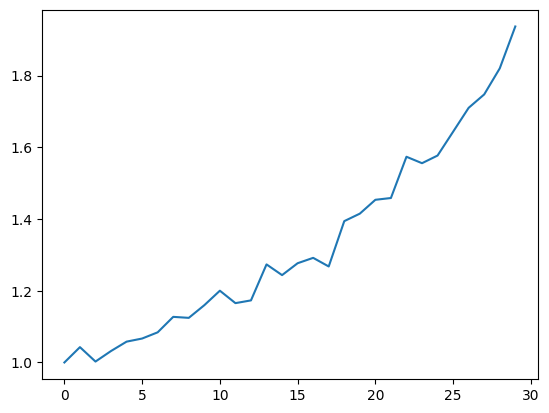

In [ ]:
Sdirect= np.ones((N,R))

for i in range(R):
    for j in range(N-1):
        increment = np.random.normal(mu*Sdirect[j,i]*T/N,sigma*Sdirect[j,i]*np.sqrt(T)/np.sqrt(N))
        Sdirect[j+1,i] =Sdirect[j,i]+increment

plt.plot(Sdirect[:,0])
plt.show()

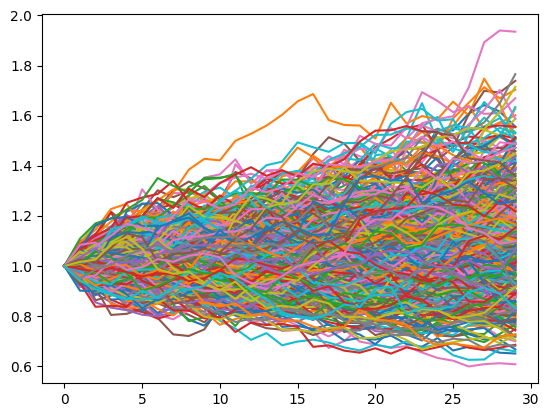

In [ ]:
for i in range(500):
   plt.plot(S[:,i])
plt.show()

In [ ]:
logX= np.zeros((N+1,R))
logX[0,]=np.log(X0)*np.ones((1,R))
alphastar= (mu-r)/(sigma**2*(1-gamma))
for i in range(R):
    for j in range(N):
        increment = np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N))
        logX[j+1,i] =logX[j,i]+increment*alphastar+r*T/N*(1-alphastar)-alphastar**2*sigma**2*T/(2*N)

X=np.exp(logX)
loss=np.mean(-np.log(X[N,:]))# np.mean(-(X[N-1,:]**gamma))
print(loss)

-0.12682231906652214


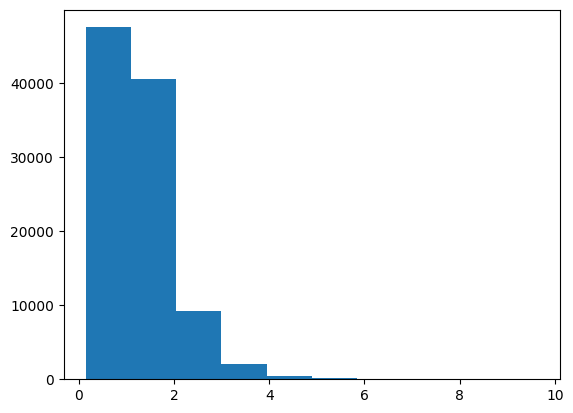

1.286375117005645
0.6858177499080164


In [ ]:
plt.hist(X[N,:])
plt.show()
print(np.mean(X[N,:]))
print(np.std(X[N,:]))

In [ ]:
#Definition of neural networks for trading strategies

m = 1 # dimension of price
d = 3 # number of layers in strategy
n = 32  # nodes in the first but last layers

# architecture is the same for all networks
layers = []
for j in range(N):
    for i in range(d):
        if i < d-1:
            nodes = n
            layer = Dense(nodes, activation='tanh',trainable=True,
                      kernel_initializer=initializers.RandomNormal(0,0.5),#kernel_initializer='random_normal',
                      bias_initializer=initializers.RandomNormal(0,0.5),
                      name=str(i)+str(j))
        else:
            nodes = m
            layer = Dense(nodes, activation='linear', trainable=True,
                          kernel_initializer=initializers.RandomNormal(0,0.5),#kernel_initializer='random_normal',
                          bias_initializer=initializers.RandomNormal(0,0.5),
                          name=str(i)+str(j))
        layers = layers + [layer]

In [ ]:
price = Input(shape=(m,))
trade = Input(shape=(m,))
tradeeval = Input(shape=(m,))
wealth = Input(shape=(1,))

inputs = [price, tradeeval, wealth] # Removed 'trade' from the initial inputs
outputhelper=[]

for j in range(N):
    strategy = wealth
    strategyeval=tradeeval
    for k in range(d):
        strategy= layers[k+(j)*d](strategy) # strategy at j is the alpha at j
        strategyeval=layers[k+(j)*d](strategyeval)
    incr = Input(shape=(m,))
    logprice= Lambda(lambda x : tf.math.log(x), output_shape=(m,))(price)
    logprice = Add()([logprice, incr])
    pricenew=Lambda(lambda x : tf.math.exp(x), output_shape=(m,))(logprice)
    price=pricenew
    logwealth= Lambda(lambda x : tf.math.log(x), output_shape=(1,))(wealth)
    logwealth= Lambda(lambda x : x+r*T/N, output_shape=(1,))(logwealth)
    helper1 = Multiply()([strategy, incr])
    #helper1 = Lambda()(lambda x : K.sum(x,axis=1))([helper1])
    logwealth = Add()([logwealth, helper1])
    helper2 = Multiply()([strategy, strategy])
    #helper2 = Lambda()(lambda x : K.sum(x,axis=1))([helper1])
    helper3 = Lambda(lambda x : x*sigma**2/2*T/N, output_shape=(1,))(helper2)
    logwealth = Subtract()([logwealth, helper3])
    helper4 = Lambda(lambda x : x*r*T/N, output_shape=(1,))(strategy)
    logwealth = Subtract()([logwealth, helper4])
    wealthnew=Lambda(lambda x : tf.math.exp(x), output_shape=(1,))(logwealth)# creating the wealth at time j+1
    inputs = inputs + [incr]
    outputhelper = outputhelper + [strategyeval] # here we collect the strategies
    wealth=wealthnew
outputs = wealth
randomendowment = Lambda(lambda x : -0.0*(tf.math.abs(x-1.0)+x-1.0), output_shape=(m,))(price)
outputs = Add()([wealth,randomendowment])
outputs = [outputs] + outputhelper
outputs = Concatenate()(outputs)

model_Merton = Model(inputs=inputs, outputs=outputs)

In [ ]:
Ktrain = 10**5
initialprice = S0
initialwealth = X0
# xtrain consists of the price S0,
#the initial hedging being 0, and dummy variables hedgeeval where the strategies are evaluated,
#the initial wealth and the increments of the log price process
xtrain = ([initialprice*np.ones((Ktrain,m))] +
          [1*np.ones((Ktrain,m))] +
          [initialwealth*np.ones((Ktrain,m))] +
          [np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N),(Ktrain,m)) for i in range(N)])

ytrain=np.zeros((Ktrain,1+N))

In [ ]:
def custom_loss(y_true,y_pred):
    z = - tf.math.log(y_pred[:,0])#-((y_pred[:,0]**gamma-1)/gamma
    z=tf.reduce_mean(z)
    return z
#def custom_loss(y_true,y_pred):
#    z = K.exp(- y_pred[:,0]*ra)#
#    z=K.mean(z)

In [ ]:
from keras import optimizers

#adam=optimizers.Adam(lr=0.01)

model_Merton.compile(optimizer='adam',loss=custom_loss)

In [ ]:
import matplotlib.pyplot as plt

for i in range(1):
    model_Merton.fit(x=xtrain,y=ytrain, epochs=10,verbose=True,batch_size=100)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 47s 14ms/step - loss: -0.1181
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: -0.1225
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: -0.1230
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: -0.1233
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: -0.1234
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: -0.1237
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: -0.1238
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: -0.1239
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: -0.1242
Epoch 10/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: -0.1241


In [ ]:
#model_Merton.summary()

In [ ]:
y_pred = model_Merton.predict(xtrain)
print(np.mean(-np.log(y_pred[:,0])))

logX= np.zeros((N+1,R))
logX[0,]=np.log(X0)*np.ones((1,R))
alpha= (mu-r)/(sigma**2*(1-gamma))
for i in range(R):
    for j in range(N):
        increment = xtrain[4+j][i] #np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N))
        logX[j+1,i] =logX[j,i]+increment*alpha+r*T/N*(1-alpha)-alpha**2*sigma**2*T/(2*N)

X=np.exp(logX)
loss=np.mean(-np.log(X[N,:]))# np.mean(-(X[N-1,:]**gamma))
print(loss)

3125/3125 [==============================] - 18s 5ms/step
-0.12383687
-0.12397950270536369


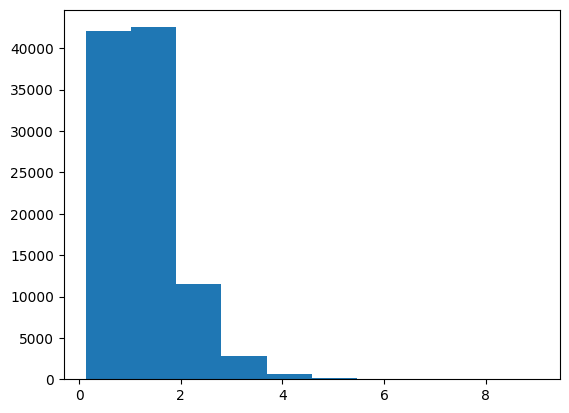

1.2913039
0.70369506


In [ ]:
plt.hist(model_Merton.predict(xtrain)[:,0])
plt.show()
print(np.mean(model_Merton.predict(xtrain)[:,0]))
print(np.std(model_Merton.predict(xtrain)[:,0]))

In [ ]:
k=10#Choose a number between 1 and N-1
Ktest=60
xtest = ([initialprice*np.ones((Ktest,m))] +
          [np.zeros((Ktest,m))]+
          [0.7*np.ones((Ktest,m))+np.cumsum(np.ones((Ktest,m))*(1.5-0.7)/Ktest,axis=0)] +#change this if you go to higher dimensions
          [initialwealth*np.ones((Ktest,m))]+
          [np.random.normal(mu*T/N,sigma*np.sqrt(T)/np.sqrt(N),(Ktest,m)) for i in range(N)])


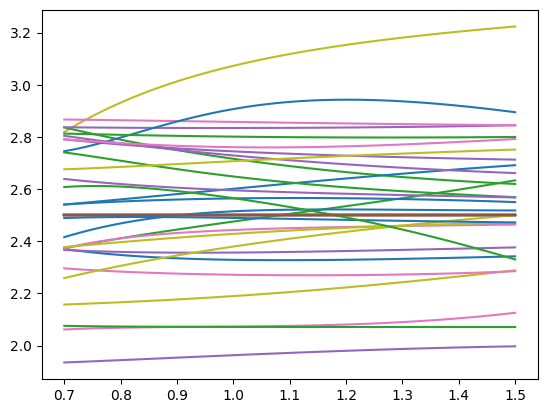

2.4999999999999996


In [ ]:
#Comparison of learned and true alpha
s=np.linspace(0.7,1.5,Ktest)

for k in range(1,N-1):
    truestrat=(mu-r)/(sigma**2*(1-gamma))*np.ones(Ktest)
    learnedstrat=model_Merton.predict(xtest)[:,k]
    plt.plot(s,learnedstrat,s,truestrat)
plt.show()
print((mu-r)/(sigma**2*(1-gamma)))